VGG19

In [ ]:
# import libraries
import os
import random
import tensorflow as tf
import cv2
import numpy as np
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D,Dense,Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# seeding
SEED=42
os.environ['PYTHONHASHSEED']=str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
# load data
from google.colab import drive
path="/content/drive/MyDrive/Fundus images/dataset"
os.listdir(path)
#count the number of images
normal_dir=os.path.join(path,"normal")
cataract_dir=os.path.join(path,"cataract")
normal_count=len(os.listdir(normal_dir))
cataract_count=len(os.listdir(cataract_dir))
print("normal_count:",normal_count)
print("cataract_count:",cataract_count)
img_size=224
x=[]  # images
y=[]  # labels
# load normal images
for img in os.listdir(normal_dir):
  img_path=os.path.join(normal_dir,img)
  img_arr=cv2.imread(img_path)
  img_arr=cv2.cvtColor(img_arr,cv2.COLOR_BGR2RGB)
  img_arr=cv2.resize(img_arr,(img_size,img_size))
  x.append(img_arr)   #image
  y.append(0)   #label
# load cataract images
for img in os.listdir(cataract_dir):
  img_path=os.path.join(cataract_dir,img)
  img_arr=cv2.imread(img_path)
  img_arr=cv2.cvtColor(img_arr,cv2.COLOR_BGR2RGB)
  img_arr=cv2.resize(img_arr,(img_size,img_size))
  x.append(img_arr)
  y.append(1)
x=np.array(x)
y=np.array(y)
x=preprocess_input(x)
print(x.shape)
print(y.shape)
from sklearn.model_selection import train_test_split
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.4, random_state=42, stratify=y)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

train_gen=ImageDataGenerator(rotation_range=10,width_shift_range=0.1,height_shift_range=0.1,zoom_range=0.2,horizontal_flip=True)
val_gen=ImageDataGenerator()

normal_count: 1074
cataract_count: 1038
(2112, 224, 224, 3)
(2112,)
(1267, 224, 224, 3)
(422, 224, 224, 3)
(423, 224, 224, 3)
(1267,)
(422,)
(423,)


In [ ]:
base_model=VGG19(weights="imagenet",include_top=False,input_shape=(img_size,img_size,3))
base_model.trainable=False
x= base_model.output
x= GlobalAveragePooling2D()(x)
x= Dense(128,activation="relu")(x)
x= Dropout(0.5)(x)
output=Dense(1,activation="sigmoid")(x)
model=Model(inputs=base_model.input,outputs=output)
model.compile(optimizer=Adam(learning_rate=1e-4),loss="binary_crossentropy",metrics=["accuracy"])
model.summary()
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights=dict(enumerate(class_weights))
print(class_weights)
history=model.fit(train_gen.flow(x_train,y_train,batch_size=32),epochs=25,validation_data=val_gen.flow(x_val,y_val),class_weight=class_weights)
#fine tuning
base_model.trainable=True
for layer in base_model.layers[:-50]:
    layer.trainable=False3

model.compile(optimizer=Adam(learning_rate=1e-4),loss="binary_crossentropy",metrics=["accuracy"])
history=model.fit(train_gen.flow(x_train,y_train,batch_size=32),epochs=15,validation_data=val_gen.flow(x_val,y_val),class_weight=class_weights)

loss,accuracy=model.evaluate(x_test,y_test)
print("loss:",loss)
print("accuracy:",accuracy)
from sklearn.metrics import classification_report,confusion_matrix
y_pred=model.predict(x_test)
y_pred=np.round(y_pred)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 20,090,177 (76.64 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

{0: np.float64(0.9836956521739131), 1: np.float64(1.0168539325842696)}


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 1131s 28s/step - accuracy: 0.4588 - loss: 2.0859 - val_accuracy: 0.8223 - val_loss: 0.4419
Epoch 2/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 1110s 28s/step - accuracy: 0.7120 - loss: 0.9591 - val_accuracy: 0.9076 - val_loss: 0.2379
Epoch 3/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 1101s 28s/step - accuracy: 0.8146 - loss: 0.5601 - val_accuracy: 0.9242 - val_loss: 0.2255
Epoch 4/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 1098s 28s/step - accuracy: 0.8580 - loss: 0.4639 - val_accuracy: 0.9336 - val_loss: 0.2150
Epoch 5/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 1113s 28s/step - accuracy: 0.8808 - loss: 0.3723 - val_accuracy: 0.9360 - val_loss: 0.2080
Epoch 6/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 1106s 28s/step - accuracy: 0.8709 - loss: 0.3663 - val_accuracy: 0.9360 - val_loss: 0.2053
Epoch 7/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 1103s 28s/step - accuracy: 0.9145 - loss: 0.2632 - val_accuracy: 0.9360 - val_loss: 0.1994
Epoch 8/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 1109s 28s/step - accuracy: 0.9078 - loss: 0.2547 - val_accu

SVM+RF

In [ ]:
# import libraries
import os
import cv2
import numpy as np
import random
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
SEED=42
os.environ['PYTHONHASHSEED']=str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
dataset_path="/content/drive/MyDrive/Fundus images/dataset"
os.listdir(dataset_path) #count the number of images
normal_dir=os.path.join(dataset_path,"normal")
cataract_dir=os.path.join(dataset_path,"cataract")
normal_count=len(os.listdir(normal_dir))
cataract_count=len(os.listdir(cataract_dir))
print("normal_count:",normal_count)
print("cataract_count:",cataract_count)
img_size=224
x=[]  # images
y=[]  # labels
# load normal images
for img in os.listdir(normal_dir):
  img_path=os.path.join(normal_dir,img)
  img_arr=cv2.imread(img_path)
  img_arr=cv2.cvtColor(img_arr,cv2.COLOR_BGR2RGB)
  img_arr=cv2.resize(img_arr,(img_size,img_size))
  x.append(img_arr)   #image
  y.append(0)   #label
# load cataract images
for img in os.listdir(cataract_dir):
  img_path=os.path.join(cataract_dir,img)
  img_arr=cv2.imread(img_path)
  img_arr=cv2.cvtColor(img_arr,cv2.COLOR_BGR2RGB)
  img_arr=cv2.resize(img_arr,(img_size,img_size))
  x.append(img_arr)
  y.append(1)
x=np.array(x)
y=np.array(y)
x=x/255.0
print(x.shape)
print(y.shape)
from sklearn.model_selection import train_test_split
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.4, random_state=42, stratify=y)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)
x_train= x_train.reshape(x_train.shape[0], -1)
x_val= x_val.reshape(x_val.shape[0], -1)
x_test= x_test.reshape(x_test.shape[0], -1)
print(x_train.shape)
print(x_test.shape)
print(x_val.shape)

normal_count: 1074
cataract_count: 1038
(2112, 224, 224, 3)
(2112,)
(1267, 224, 224, 3)
(422, 224, 224, 3)
(423, 224, 224, 3)
(1267,)
(422,)
(423,)
(1267, 150528)
(423, 150528)
(422, 150528)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import log_loss
# Create SVM classifier
svm_model = SVC(kernel='linear', probability=True, random_state=42)
# Create RF Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train SVM
svm_model.fit(x_train, y_train)
# Train RF
rf_model.fit(x_train, y_train)

# Test set
svm_test_proba = svm_model.predict_proba(x_test)
rf_test_proba  = rf_model.predict_proba(x_test)

avg_test_proba = (svm_test_proba + rf_test_proba) / 2
y_test_pred_ensemble = np.argmax(avg_test_proba, axis=1)

print("SVM + RF Test Accuracy:",
      accuracy_score(y_test, y_test_pred_ensemble))

test_loss = log_loss(y_test, avg_test_proba)
print("SVM + RF Test Log Loss:", test_loss)

print("Test Classification Report:\n",
      classification_report(y_test, y_test_pred_ensemble))
print("Test Confusion Matrix:\n",
      confusion_matrix(y_test, y_test_pred_ensemble))

SVM + RF Test Accuracy: 0.8723404255319149
SVM + RF Test Log Loss: 0.292484294482537
Test Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.91      0.88       215
           1       0.90      0.83      0.86       208

    accuracy                           0.87       423
   macro avg       0.87      0.87      0.87       423
weighted avg       0.87      0.87      0.87       423

Test Confusion Matrix:
 [[196  19]
 [ 35 173]]


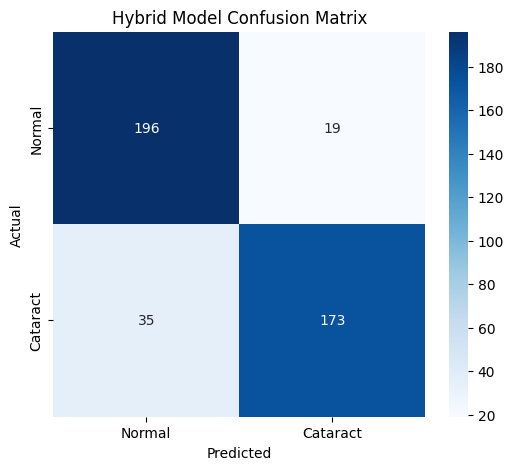

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred_ensemble)
labels = ['Normal', 'Cataract']

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Hybrid Model Confusion Matrix')
plt.show()


Train Accuracy: 1.0
Validation Accuracy: 0.8696682464454977


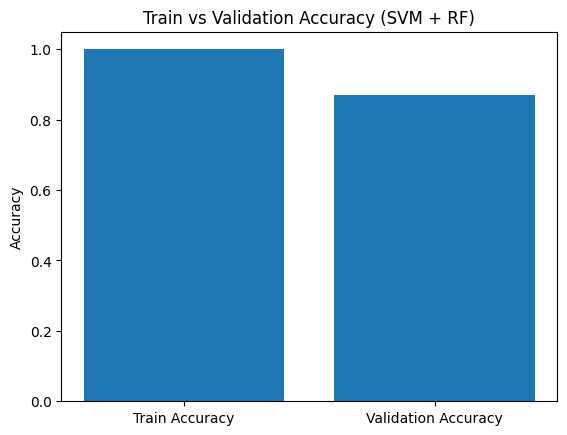

In [ ]:
# Validation predictions
val_pred_proba = (svm_model.predict_proba(x_val) + rf_model.predict_proba(x_val)) / 2
y_val_pred = np.argmax(val_pred_proba, axis=1)

# Train predictions
train_pred_proba = (svm_model.predict_proba(x_train) + rf_model.predict_proba(x_train)) / 2
y_train_pred = np.argmax(train_pred_proba, axis=1)

from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)

# Plot
import matplotlib.pyplot as plt

plt.figure()
plt.bar(['Train Accuracy', 'Validation Accuracy'], [train_acc, val_acc])
plt.title('Train vs Validation Accuracy (SVM + RF)')
plt.ylabel('Accuracy')
plt.show()

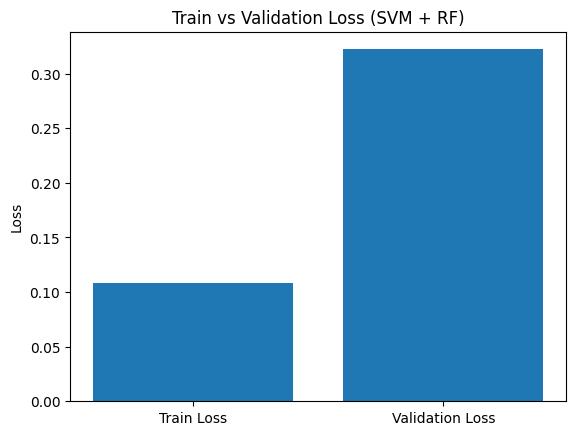

In [ ]:
from sklearn.metrics import log_loss

train_loss = log_loss(y_train, train_pred_proba)
val_loss = log_loss(y_val, val_pred_proba)

plt.figure()
plt.bar(['Train Loss', 'Validation Loss'], [train_loss, val_loss])
plt.title('Train vs Validation Loss (SVM + RF)')
plt.ylabel('Loss')
plt.show()

AUC Score: 0.9557245080500895


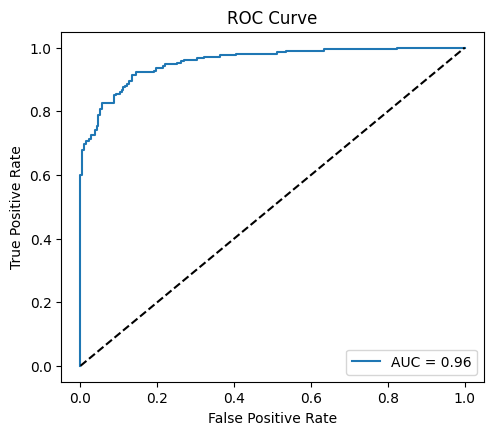

In [ ]:
from sklearn.metrics import roc_curve, auc, accuracy_score, log_loss
import matplotlib.pyplot as plt
fpr, tpr, _ = roc_curve(y_test, avg_test_proba[:, 1])
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)
plt.figure(figsize=(12,10))
# 1. ROC Curve
plt.subplot(2,2,1)
plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.plot([0,1],[0,1],'k--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()


In [ ]:
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import cv2
uploaded = files.upload()
for fname in uploaded.keys():
    # Load image
    img = load_img(fname, target_size=(img_size, img_size))
    img = img_to_array(img)

    # Normalize (same as training)
    img = img / 255.0

    # Flatten (VERY IMPORTANT)
    img = img.reshape(1, -1)

    # Predict using SVM
    prediction = svm_model.predict(img)

    label = "Cataract" if prediction[0] == 1 else "Normal"
    print(f"{fname}: {label}")


Saving nor5.jpg to nor5 (2).jpg
Saving c5.jpg to c5 (2).jpg
Saving c4.jpg to c4 (2).jpg
Saving Cataract image.jpg to Cataract image (2).jpg
Saving c2.jpg to c2 (2).jpg
Saving c1.jpg to c1 (2).jpg
Saving nor4.jpg to nor4 (2).jpg
Saving Normal Image.jpg to Normal Image (2).jpg
Saving nor2.jpg to nor2 (2).jpg
Saving nor1.jpg to nor1 (2).jpg
nor5 (2).jpg: Normal
c5 (2).jpg: Cataract
c4 (2).jpg: Cataract
Cataract image (2).jpg: Cataract
c2 (2).jpg: Cataract
c1 (2).jpg: Cataract
nor4 (2).jpg: Normal
Normal Image (2).jpg: Normal
nor2 (2).jpg: Cataract
nor1 (2).jpg: Cataract


EfficientNet+SVM+RF

In [ ]:
# import libraries
import os
import cv2
import tensorflow as tf
import random
import numpy as np
# load model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# seeding
SEED=42
os.environ['PYTHONHASHSEED']=str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
dataset_path="/content/drive/MyDrive/Fundus images/dataset"
os.listdir(dataset_path)#count the number of images
normal_dir=os.path.join(dataset_path,"normal")
cataract_dir=os.path.join(dataset_path,"cataract")
normal_count=len(os.listdir(normal_dir))
cataract_count=len(os.listdir(cataract_dir))
print("normal_count:",normal_count)
print("cataract_count:",cataract_count)
img_size=224
x=[]  # images
y=[]  # labels
# load normal images
for img in os.listdir(normal_dir):
  img_path=os.path.join(normal_dir,img)
  img_arr=cv2.imread(img_path)
  img_arr=cv2.cvtColor(img_arr,cv2.COLOR_BGR2RGB)
  img_arr=cv2.resize(img_arr,(img_size,img_size))
  x.append(img_arr)   #image
  y.append(0)   #label
# load cataract images
for img in os.listdir(cataract_dir):
  img_path=os.path.join(cataract_dir,img)
  img_arr=cv2.imread(img_path)
  img_arr=cv2.cvtColor(img_arr,cv2.COLOR_BGR2RGB)
  img_arr=cv2.resize(img_arr,(img_size,img_size))
  x.append(img_arr)
  y.append(1)
x=np.array(x)
y=np.array(y)
x=preprocess_input(x)
print(x.shape)
print(y.shape)
from sklearn.model_selection import train_test_split
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.4, random_state=42, stratify=y)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

normal_count: 1074
cataract_count: 1038
(2112, 224, 224, 3)
(2112,)
(1267, 224, 224, 3)
(422, 224, 224, 3)
(423, 224, 224, 3)
(1267,)
(422,)
(423,)


In [ ]:
train_datagen = ImageDataGenerator(rotation_range=20,zoom_range=0.15,width_shift_range=0.1,height_shift_range=0.1,horizontal_flip=True,fill_mode="nearest")
val_datagen = ImageDataGenerator()

base_model=EfficientNetB0(weights="imagenet",include_top=False,input_shape=(img_size,img_size,3))
# freeze some layers
for layer in base_model.layers:
  layer.trainable= False
for layer in base_model.layers[:-50]:
  layer.trainable= True
x= base_model.output
x= GlobalAveragePooling2D()(x)
feature_extractor= Model(inputs=base_model.input,outputs=x)
print(feature_extractor.summary())
# extract features
x_train_features=feature_extractor.predict(x_train)
x_test_features=feature_extractor.predict(x_test)
x_val_features=feature_extractor.predict(x_val)
print(x_train_features.shape)
print(x_test_features.shape)
print(x_val_features.shape)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train_features)
x_test_scaled=scaler.transform(x_test_features)
x_val_scaled=scaler.transform(x_val_features)

# train svm
svm_model=SVC(kernel="linear",probability=True,class_weight="balanced",random_state=SEED)
svm_model.fit(x_train_scaled,y_train)
# train random forest
rf_model=RandomForestClassifier(n_estimators=100,random_state=SEED)
rf_model.fit(x_train_scaled,y_train)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 1,480,684 (5.65 MB)

 Non-trainable params: 2,568,887 (9.80 MB)

None
40/40 ━━━━━━━━━━━━━━━━━━━━ 127s 3s/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step
(1267, 1280)
(423, 1280)
(422, 1280)


RandomForestClassifier(random_state=42)

In [ ]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import log_loss

# Probability predictions
svm_probs = svm_model.predict_proba(x_test_scaled)
rf_probs = rf_model.predict_proba(x_test_scaled)

# Hybrid (soft voting)
hybrid_probs = (svm_probs + rf_probs) / 2
hybrid_pred = np.argmax(hybrid_probs, axis=1)

# Hybrid (soft voting)
hybrid_probs = (svm_probs + rf_probs) / 2
hybrid_pred = np.argmax(hybrid_probs, axis=1)

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Hybrid Accuracy:", accuracy_score(y_test, hybrid_pred))
hybrid_loss = log_loss(y_test, hybrid_probs)
print("Hybrid Log Loss:", hybrid_loss)
print("Confusion Matrix:\n", confusion_matrix(y_test, hybrid_pred))
print("Classification Report:\n", classification_report(y_test, hybrid_pred))

Hybrid Accuracy: 0.9739952718676123
Hybrid Log Loss: 0.09630812332359644
Confusion Matrix:
 [[210   5]
 [  6 202]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97       215
           1       0.98      0.97      0.97       208

    accuracy                           0.97       423
   macro avg       0.97      0.97      0.97       423
weighted avg       0.97      0.97      0.97       423



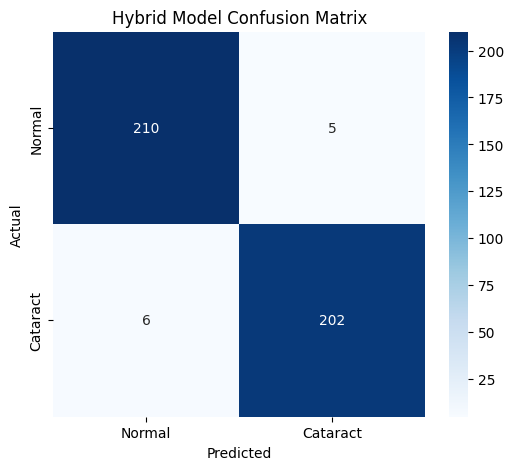

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, hybrid_pred)
labels = ['Normal', 'Cataract']

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Hybrid Model Confusion Matrix')
plt.show()


AUC Score: 0.9947898032200359
Train Accuracy: 1.0
Validation Accuracy: 0.966824644549763


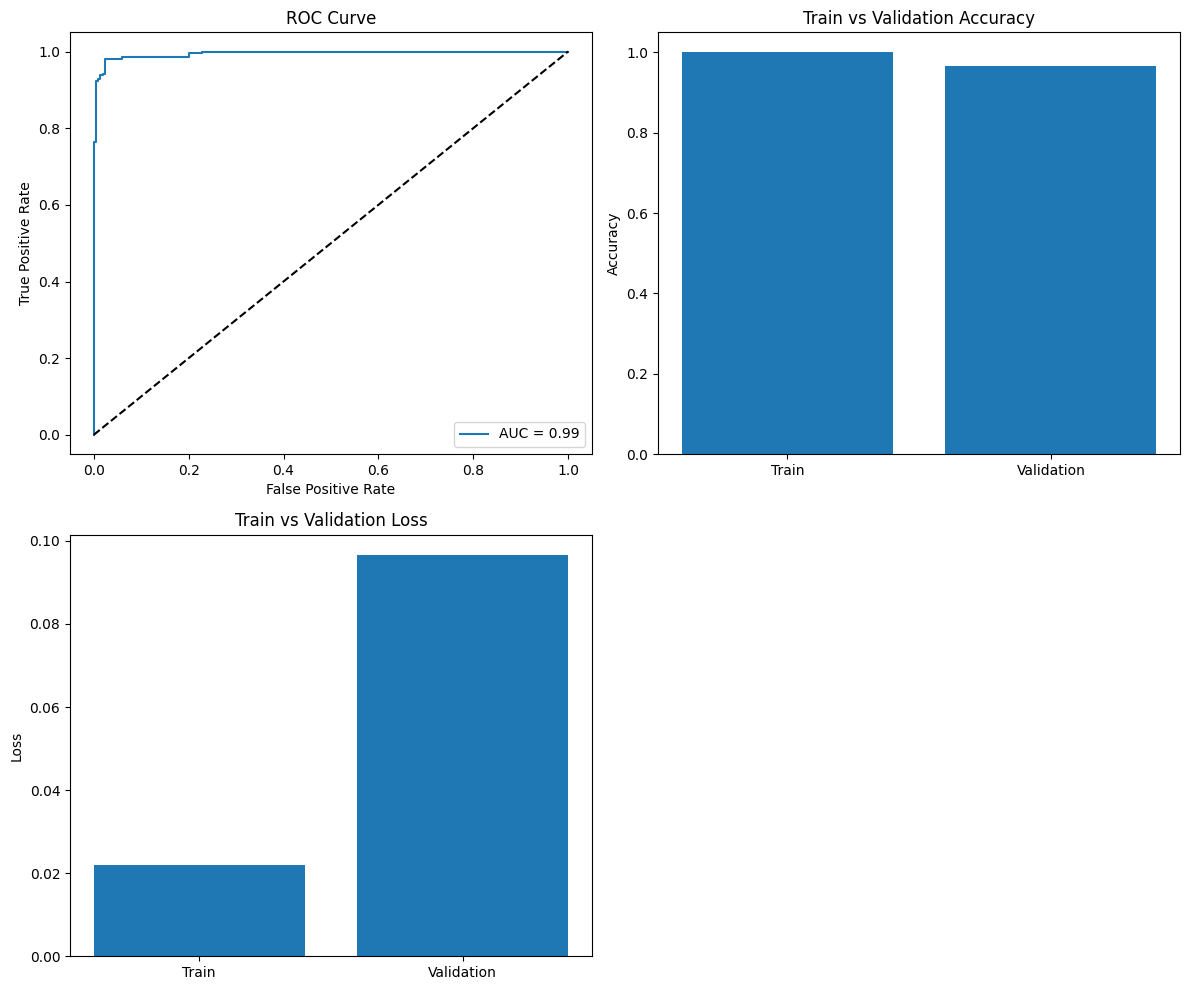

In [ ]:
from sklearn.metrics import roc_curve, auc, accuracy_score, log_loss
import matplotlib.pyplot as plt

# ------------------ ROC + AUC ------------------
y_prob = hybrid_probs[:, 1]   # probability of class 1

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

# ------------------ Train & Validation ------------------

# Train predictions
svm_train_probs = svm_model.predict_proba(x_train_scaled)
rf_train_probs  = rf_model.predict_proba(x_train_scaled)
train_probs = (svm_train_probs + rf_train_probs) / 2
train_pred = np.argmax(train_probs, axis=1)

# Validation predictions
svm_val_probs = svm_model.predict_proba(x_val_scaled)
rf_val_probs  = rf_model.predict_proba(x_val_scaled)
val_probs = (svm_val_probs + rf_val_probs) / 2
val_pred = np.argmax(val_probs, axis=1)

# Accuracy
train_acc = accuracy_score(y_train, train_pred)
val_acc   = accuracy_score(y_val, val_pred)

# Loss
train_loss = log_loss(y_train, train_probs)
val_loss   = log_loss(y_val, val_probs)

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)

# ------------------ COMBINED PLOT ------------------
plt.figure(figsize=(12,10))

# 1. ROC Curve
plt.subplot(2,2,1)
plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.plot([0,1],[0,1],'k--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

# 2. Train vs Validation Accuracy
plt.subplot(2,2,2)
plt.bar(['Train','Validation'], [train_acc, val_acc])
plt.title('Train vs Validation Accuracy')
plt.ylabel('Accuracy')

# 3. Train vs Validation Loss
plt.subplot(2,2,3)
plt.bar(['Train','Validation'], [train_loss, val_loss])
plt.title('Train vs Validation Loss')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
uploaded = files.upload()

for fname in uploaded.keys():
  img = load_img(fname, target_size=(img_size, img_size))
  img = img_to_array(img)
  img = np.expand_dims(img, axis=0)
  img = preprocess_input(img)

    # Extract features
  img_feat = feature_extractor.predict(img, verbose=0)

    # Scale features
  img_feat_scaled = scaler.transform(img_feat)

    # Predict probabilities
  svm_prob = svm_model.predict_proba(img_feat_scaled)
  rf_prob  = rf_model.predict_proba(img_feat_scaled)

    # Hybrid soft voting
  hybrid_prob = (svm_prob + rf_prob) / 2
  pred_class = np.argmax(hybrid_prob, axis=1)[0]
  confidence = hybrid_prob[0][pred_class]

    # Correct label mapping
  label = "Normal" if pred_class == 0 else "Cataract"

  print(f"{fname} -> Prediction: {label}, Confidence: {confidence:.2f}")


Saving nor5.jpg to nor5.jpg
Saving c5.jpg to c5.jpg
Saving c4.jpg to c4.jpg
Saving Cataract image.jpg to Cataract image.jpg
Saving c2.jpg to c2.jpg
Saving c1.jpg to c1.jpg
Saving nor4.jpg to nor4.jpg
Saving Normal Image.jpg to Normal Image.jpg
Saving nor2.jpg to nor2.jpg
Saving nor1.jpg to nor1.jpg
nor5.jpg -> Prediction: Normal, Confidence: 0.92
c5.jpg -> Prediction: Cataract, Confidence: 0.95
c4.jpg -> Prediction: Cataract, Confidence: 0.97
Cataract image.jpg -> Prediction: Cataract, Confidence: 0.96
c2.jpg -> Prediction: Cataract, Confidence: 0.76
c1.jpg -> Prediction: Cataract, Confidence: 0.97
nor4.jpg -> Prediction: Normal, Confidence: 0.99
Normal Image.jpg -> Prediction: Normal, Confidence: 0.99
nor2.jpg -> Prediction: Normal, Confidence: 0.72
nor1.jpg -> Prediction: Normal, Confidence: 0.95


ResNet101+SVM+RF

In [ ]:
# import libraries
import os
import cv2
import tensorflow as tf
import random
import numpy as np
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# seeding
SEED=42
os.environ['PYTHONHASHSEED']=str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
dataset_path="/content/drive/MyDrive/Fundus images/dataset"
os.listdir(dataset_path)#count the number of images
normal_dir=os.path.join(dataset_path,"normal")
cataract_dir=os.path.join(dataset_path,"cataract")
normal_count=len(os.listdir(normal_dir))
cataract_count=len(os.listdir(cataract_dir))
print("normal_count:",normal_count)
print("cataract_count:",cataract_count)
img_size=224
x=[]  # images
y=[]  # labels
# load normal images
for img in os.listdir(normal_dir):
  img_path=os.path.join(normal_dir,img)
  img_arr=cv2.imread(img_path)
  img_arr=cv2.cvtColor(img_arr,cv2.COLOR_BGR2RGB)
  img_arr=cv2.resize(img_arr,(img_size,img_size))
  x.append(img_arr)   #image
  y.append(0)   #label
# load cataract images
for img in os.listdir(cataract_dir):
  img_path=os.path.join(cataract_dir,img)
  img_arr=cv2.imread(img_path)
  img_arr=cv2.cvtColor(img_arr,cv2.COLOR_BGR2RGB)
  img_arr=cv2.resize(img_arr,(img_size,img_size))
  x.append(img_arr)
  y.append(1)
x=np.array(x)
y=np.array(y)
x=preprocess_input(x)
print(x.shape)
print(y.shape)
from sklearn.model_selection import train_test_split
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.4, random_state=42, stratify=y)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

normal_count: 1074
cataract_count: 1038
(2112, 224, 224, 3)
(2112,)
(1267, 224, 224, 3)
(422, 224, 224, 3)
(423, 224, 224, 3)
(1267,)
(422,)
(423,)


In [ ]:
train_datagen = ImageDataGenerator(rotation_range=20,zoom_range=0.15,width_shift_range=0.1,height_shift_range=0.1,horizontal_flip=True,fill_mode="nearest")
val_datagen = ImageDataGenerator()
# load model
base_model=ResNet101(weights="imagenet",include_top=False,input_shape=(img_size,img_size,3))
# freeze some layers
for layer in base_model.layers:
  layer.trainable= False
for layer in base_model.layers[:-50]:
  layer.trainable= True
x= base_model.output
x= GlobalAveragePooling2D()(x)
feature_extractor= Model(inputs=base_model.input,outputs=x)
print(feature_extractor.summary())
# extract features
x_train_features=feature_extractor.predict(x_train)
x_test_features=feature_extractor.predict(x_test)
x_val_features=feature_extractor.predict(x_val)
print(x_train_features.shape)
print(x_test_features.shape)
print(x_val_features.shape)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train_features)
x_test_scaled=scaler.transform(x_test_features)
x_val_scaled=scaler.transform(x_val_features)

# train svm
svm_model=SVC(kernel="linear",probability=True,class_weight="balanced",random_state=SEED)
svm_model.fit(x_train_scaled,y_train)
# train random forest
rf_model=RandomForestClassifier(n_estimators=100,random_state=SEED)
rf_model.fit(x_train_scaled,y_train)


171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 42,658,176 (162.73 MB)

 Trainable params: 25,602,304 (97.67 MB)

 Non-trainable params: 17,055,872 (65.06 MB)

None
40/40 ━━━━━━━━━━━━━━━━━━━━ 387s 10s/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 126s 9s/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 132s 10s/step
(1267, 2048)
(423, 2048)
(422, 2048)


RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import log_loss
# Probability predictions
svm_probs = svm_model.predict_proba(x_test_scaled)
rf_probs = rf_model.predict_proba(x_test_scaled)
# Hybrid
hybrid_probs = (svm_probs + rf_probs) / 2
hybrid_pred = np.argmax(hybrid_probs, axis=1)

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Hybrid Accuracy:", accuracy_score(y_test, hybrid_pred))
hybrid_loss = log_loss(y_test, hybrid_probs)
print("Hybrid Log Loss:", hybrid_loss)
print("Confusion Matrix:\n", confusion_matrix(y_test, hybrid_pred))
print("Classification Report:\n", classification_report(y_test, hybrid_pred))

Hybrid Accuracy: 0.9739952718676123
Hybrid Log Loss: 0.10176733937709849
Confusion Matrix:
 [[209   6]
 [  5 203]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.97       215
           1       0.97      0.98      0.97       208

    accuracy                           0.97       423
   macro avg       0.97      0.97      0.97       423
weighted avg       0.97      0.97      0.97       423



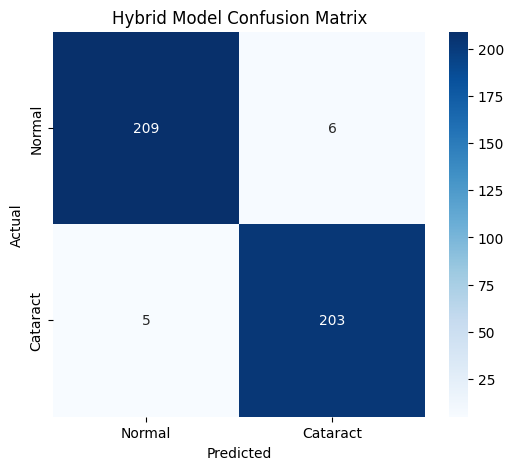

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, hybrid_pred)
labels = ['Normal', 'Cataract']

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Hybrid Model Confusion Matrix')
plt.show()


AUC Score: 0.9945661896243292
Train Accuracy: 1.0
Validation Accuracy: 0.9691943127962085


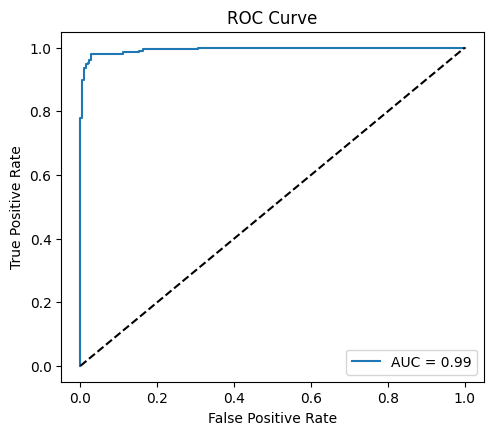

In [ ]:
from sklearn.metrics import roc_curve, auc, accuracy_score, log_loss
import matplotlib.pyplot as plt

# ------------------ ROC + AUC ------------------
y_prob = hybrid_probs[:, 1]   # probability of class 1
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
print("AUC Score:", roc_auc)

# ------------------ Train & Validation ------------------

# Train predictions
svm_train_probs = svm_model.predict_proba(x_train_scaled)
rf_train_probs  = rf_model.predict_proba(x_train_scaled)
train_probs = (svm_train_probs + rf_train_probs) / 2
train_pred = np.argmax(train_probs, axis=1)

# Validation predictions
svm_val_probs = svm_model.predict_proba(x_val_scaled)
rf_val_probs  = rf_model.predict_proba(x_val_scaled)
val_probs = (svm_val_probs + rf_val_probs) / 2
val_pred = np.argmax(val_probs, axis=1)

# Accuracy
train_acc = accuracy_score(y_train, train_pred)
val_acc   = accuracy_score(y_val, val_pred)

# Loss
train_loss = log_loss(y_train, train_probs)
val_loss   = log_loss(y_val, val_probs)

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)

# ------------------ COMBINED PLOT ------------------
plt.figure(figsize=(12,10))

# 1. ROC Curve
plt.subplot(2,2,1)
plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.plot([0,1],[0,1],'k--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

# # 2. Train vs Validation Accuracy
# plt.subplot(2,2,2)
# plt.bar(['Train','Validation'], [train_acc, val_acc])
# plt.title('Train vs Validation Accuracy')
# plt.ylabel('Accuracy')

# # 3. Train vs Validation Loss
# plt.subplot(2,2,3)
# plt.bar(['Train','Validation'], [train_loss, val_loss])
# plt.title('Train vs Validation Loss')
# plt.ylabel('Loss')

# plt.tight_layout()
# plt.show()

AUC Score: 0.9945661896243292


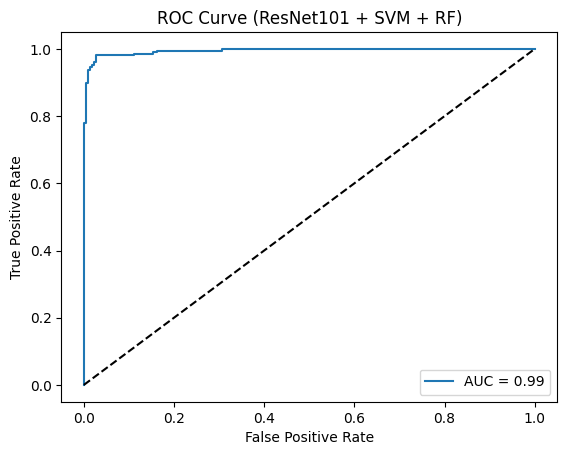

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# use probability of positive class (cataract = 1)
y_prob = hybrid_probs[:, 1]

# compute ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# compute AUC
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

# plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')  # random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (ResNet101 + SVM + RF)')
plt.legend(loc='lower right')
plt.show()

In [ ]:
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
uploaded = files.upload()

for fname in uploaded.keys():
  img = load_img(fname, target_size=(img_size, img_size))
  img = img_to_array(img)
  img = np.expand_dims(img, axis=0)
  img = preprocess_input(img)

    # Extract features
  img_feat = feature_extractor.predict(img, verbose=0)

    # Scale features
  img_feat_scaled = scaler.transform(img_feat)

    # Predict probabilities
  svm_prob = svm_model.predict_proba(img_feat_scaled)
  rf_prob  = rf_model.predict_proba(img_feat_scaled)

    # Hybrid soft voting
  hybrid_prob = (svm_prob + rf_prob) / 2
  pred_class = np.argmax(hybrid_prob, axis=1)[0]
  confidence = hybrid_prob[0][pred_class]

    # Correct label mapping
  label = "Normal" if pred_class == 0 else "Cataract"

  print(f"{fname} -> Prediction: {label}, Confidence: {confidence:.2f}")


Saving nor5.jpg to nor5 (1).jpg
Saving c5.jpg to c5 (1).jpg
Saving c4.jpg to c4 (1).jpg
Saving Cataract image.jpg to Cataract image (2).jpg
Saving c2.jpg to c2 (1).jpg
Saving c1.jpg to c1 (1).jpg
Saving nor4.jpg to nor4 (1).jpg
Saving Normal Image.jpg to Normal Image (2).jpg
Saving nor2.jpg to nor2 (1).jpg
Saving nor1.jpg to nor1 (1).jpg
nor5 (1).jpg -> Prediction: Normal, Confidence: 0.87
c5 (1).jpg -> Prediction: Cataract, Confidence: 0.89
c4 (1).jpg -> Prediction: Cataract, Confidence: 0.94
Cataract image (2).jpg -> Prediction: Cataract, Confidence: 0.96
c2 (1).jpg -> Prediction: Normal, Confidence: 0.54
c1 (1).jpg -> Prediction: Cataract, Confidence: 0.91
nor4 (1).jpg -> Prediction: Normal, Confidence: 0.99
Normal Image (2).jpg -> Prediction: Normal, Confidence: 0.97
nor2 (1).jpg -> Prediction: Normal, Confidence: 0.82
nor1 (1).jpg -> Prediction: Normal, Confidence: 0.75


VGG19+SVM

In [ ]:
# import libraries
import os
import cv2
import tensorflow as tf
import random
import numpy as np
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.svm import SVC
from tensorflow.keras.preprocessing.image import ImageDataGenerator
SEED=42
os.environ['PYTHONHASHSEED']=str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [ ]:
dataset_path="/content/drive/MyDrive/Fundus images/dataset"
os.listdir(dataset_path)#count the number of images
normal_dir=os.path.join(dataset_path,"normal")
cataract_dir=os.path.join(dataset_path,"cataract")
normal_count=len(os.listdir(normal_dir))
cataract_count=len(os.listdir(cataract_dir))
print("normal_count:",normal_count)
print("cataract_count:",cataract_count)
img_size=224
x=[]  # images
y=[]  # labels
# load normal images
for img in os.listdir(normal_dir):
  img_path=os.path.join(normal_dir,img)
  img_arr=cv2.imread(img_path)
  img_arr=cv2.cvtColor(img_arr,cv2.COLOR_BGR2RGB)
  img_arr=cv2.resize(img_arr,(img_size,img_size))
  x.append(img_arr)   #image
  y.append(0)   #label
# load cataract images
for img in os.listdir(cataract_dir):
  img_path=os.path.join(cataract_dir,img)
  img_arr=cv2.imread(img_path)
  img_arr=cv2.cvtColor(img_arr,cv2.COLOR_BGR2RGB)
  img_arr=cv2.resize(img_arr,(img_size,img_size))
  x.append(img_arr)
  y.append(1)
x=np.array(x)
y=np.array(y)
x=preprocess_input(x)
print(x.shape)
print(y.shape)
from sklearn.model_selection import train_test_split
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.4, random_state=42, stratify=y)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

normal_count: 1074
cataract_count: 1038
(2112, 224, 224, 3)
(2112,)
(1267, 224, 224, 3)
(422, 224, 224, 3)
(423, 224, 224, 3)
(1267,)
(422,)
(423,)


In [ ]:
train_datagen = ImageDataGenerator(rotation_range=20,zoom_range=0.15,width_shift_range=0.1,height_shift_range=0.1,horizontal_flip=True,fill_mode="nearest")
val_datagen = ImageDataGenerator()
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# load model
base_model=VGG19(weights="imagenet",include_top=False,input_shape=(img_size,img_size,3))
# freeze some layers
for layer in base_model.layers:
  layer.trainable= False
x= base_model.output
x= GlobalAveragePooling2D()(x)
feature_extractor= Model(inputs=base_model.input,outputs=x)
print(feature_extractor.summary())
# extract features
x_train_features=feature_extractor.predict(x_train)
x_test_features=feature_extractor.predict(x_test)
x_val_features=feature_extractor.predict(x_val)
print(x_train_features.shape)
print(x_test_features.shape)
print(x_val_features.shape)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train_features)
x_test_scaled=scaler.transform(x_test_features)
x_val_scaled=scaler.transform(x_val_features)

# train svm
svm_model=SVC(kernel="linear",probability=True,class_weight="balanced",random_state=SEED)
svm_model.fit(x_train_scaled,y_train)
svm_pred=svm_model.predict(x_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("SVM Log Loss:", log_loss(y_test, svm_model.predict_proba(x_test_scaled)))
print("Confusion Matrix:\n", confusion_matrix(y_test, svm_pred))
print("Classification Report:\n", classification_report(y_test, svm_pred))


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,024,384 (76.39 MB)

None
40/40 ━━━━━━━━━━━━━━━━━━━━ 949s 24s/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 289s 20s/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 290s 21s/step
(1267, 512)
(423, 512)
(422, 512)
SVM Accuracy: 0.950354609929078
SVM Log Loss: 0.1374495754368868
Confusion Matrix:
 [[201  14]
 [  7 201]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.93      0.95       215
           1       0.93      0.97      0.95       208

    accuracy                           0.95       423
   macro avg       0.95      0.95      0.95       423
weighted avg       0.95      0.95      0.95       423



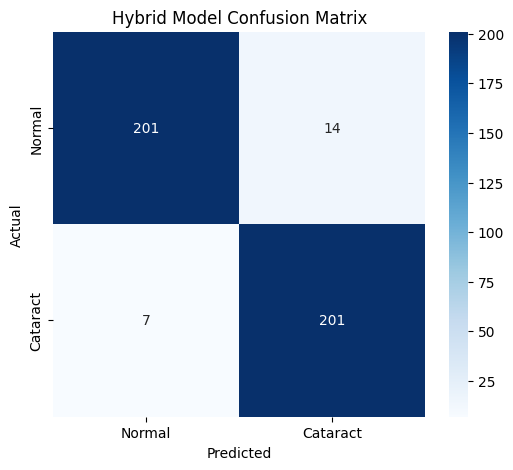

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, svm_pred)

labels = ['Normal', 'Cataract']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Hybrid Model Confusion Matrix')
plt.show()


AUC Score: 0.9889087656529517


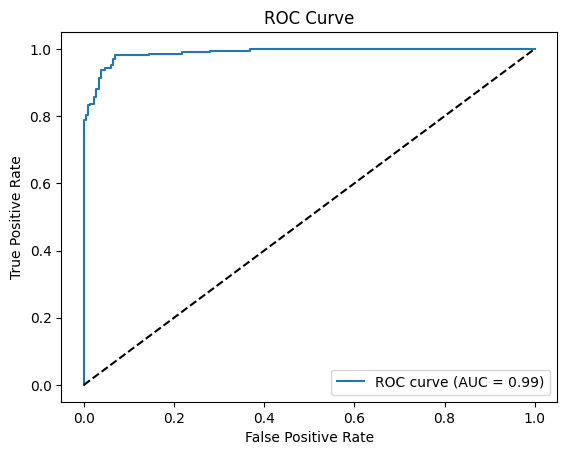

In [ ]:
from sklearn.metrics import roc_curve, auc
y_prob = svm_model.predict_proba(x_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
print("AUC Score:", roc_auc)
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array

uploaded = files.upload()
for fname in uploaded.keys():
    img = load_img(fname, target_size=(img_size, img_size))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)

    # Feature extraction
    img_feat = feature_extractor.predict(img, verbose=0)
    img_feat_scaled = scaler.transform(img_feat)

    # SVM prediction
    pred_class = svm_model.predict(img_feat_scaled)[0]
    label = "Normal" if pred_class == 0 else "Cataract"
    print(f"{fname} -> Prediction: {label}")

Saving nor5.jpg to nor5 (5).jpg
Saving c5.jpg to c5 (5).jpg
Saving c4.jpg to c4 (5).jpg
Saving Cataract image.jpg to Cataract image (6).jpg
Saving c2.jpg to c2 (7).jpg
Saving c1.jpg to c1 (6).jpg
Saving nor4.jpg to nor4 (5).jpg
Saving Normal Image.jpg to Normal Image (6).jpg
Saving nor2.jpg to nor2 (5).jpg
Saving nor1.jpg to nor1 (5).jpg
nor5 (5).jpg -> Prediction: Normal
c5 (5).jpg -> Prediction: Cataract
c4 (5).jpg -> Prediction: Cataract
Cataract image (6).jpg -> Prediction: Cataract
c2 (7).jpg -> Prediction: Cataract
c1 (6).jpg -> Prediction: Cataract
nor4 (5).jpg -> Prediction: Normal
Normal Image (6).jpg -> Prediction: Normal
nor2 (5).jpg -> Prediction: Cataract
nor1 (5).jpg -> Prediction: Normal


ResNet101+kNN

In [ ]:
# import libraries
import os
import cv2
import tensorflow as tf
import random
import numpy as np
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# seeding
SEED=42
os.environ['PYTHONHASHSEED']=str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
dataset_path="/content/drive/MyDrive/Fundus images/dataset"
os.listdir(dataset_path)#count the number of images
normal_dir=os.path.join(dataset_path,"normal")
cataract_dir=os.path.join(dataset_path,"cataract")
normal_count=len(os.listdir(normal_dir))
cataract_count=len(os.listdir(cataract_dir))
print("normal_count:",normal_count)
print("cataract_count:",cataract_count)
img_size=224
x=[]  # images
y=[]  # labels
# load normal images
for img in os.listdir(normal_dir):
  img_path=os.path.join(normal_dir,img)
  img_arr=cv2.imread(img_path)
  img_arr=cv2.cvtColor(img_arr,cv2.COLOR_BGR2RGB)
  img_arr=cv2.resize(img_arr,(img_size,img_size))
  x.append(img_arr)   #image
  y.append(0)   #label
# load cataract images
for img in os.listdir(cataract_dir):
  img_path=os.path.join(cataract_dir,img)
  img_arr=cv2.imread(img_path)
  img_arr=cv2.cvtColor(img_arr,cv2.COLOR_BGR2RGB)
  img_arr=cv2.resize(img_arr,(img_size,img_size))
  x.append(img_arr)
  y.append(1)
x=np.array(x)
y=np.array(y)
x=preprocess_input(x)
print(x.shape)
print(y.shape)
from sklearn.model_selection import train_test_split
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.4, random_state=42, stratify=y)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

normal_count: 1074
cataract_count: 1038
(2112, 224, 224, 3)
(2112,)
(1267, 224, 224, 3)
(422, 224, 224, 3)
(423, 224, 224, 3)
(1267,)
(422,)
(423,)


In [ ]:
train_datagen = ImageDataGenerator(rotation_range=20,zoom_range=0.15,width_shift_range=0.1,height_shift_range=0.1,horizontal_flip=True,fill_mode="nearest")
val_datagen = ImageDataGenerator()
# load model
base_model=ResNet101(weights="imagenet",include_top=False,input_shape=(img_size,img_size,3))
# freeze some layers
for layer in base_model.layers:
  layer.trainable= False
x= base_model.output
x= GlobalAveragePooling2D()(x)
feature_extractor= Model(inputs=base_model.input,outputs=x)
print(feature_extractor.summary())
# extract features
x_train_features=feature_extractor.predict(x_train)
x_test_features=feature_extractor.predict(x_test)
x_val_features=feature_extractor.predict(x_val)
print(x_train_features.shape)
print(x_test_features.shape)
print(x_val_features.shape)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train_features)
x_test_scaled=scaler.transform(x_test_features)
x_val_scaled=scaler.transform(x_val_features)

# train knn
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled, y_train)
# Predict & Evaluate
knn_pred = knn_model.predict(x_test_scaled)
knn_probs = knn_model.predict_proba(x_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print("KNN Log Loss:", log_loss(y_test, knn_probs))

print("Confusion Matrix:\n", confusion_matrix(y_test, knn_pred))
print("Classification Report:\n", classification_report(y_test, knn_pred))


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 42,658,176 (162.73 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 42,658,176 (162.73 MB)

None
40/40 ━━━━━━━━━━━━━━━━━━━━ 416s 10s/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 124s 9s/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 125s 9s/step
(1267, 2048)
(423, 2048)
(422, 2048)
KNN Accuracy: 0.966903073286052
KNN Log Loss: 0.41189293824540485
Confusion Matrix:
 [[205  10]
 [  4 204]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.97       215
           1       0.95      0.98      0.97       208

    accuracy                           0.97       423
   macro avg       0.97      0.97      0.97       423
weighted avg       0.97      0.97      0.97       423



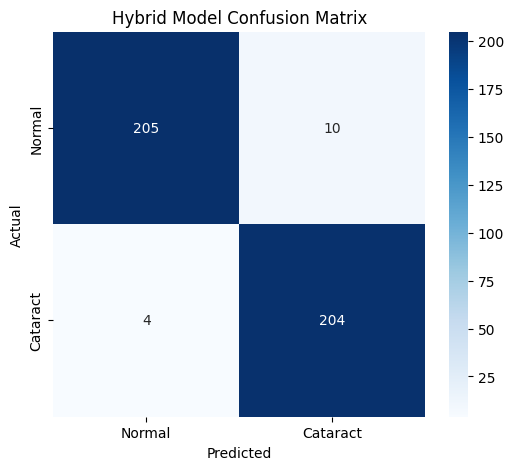

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, knn_pred)
labels = ['Normal', 'Cataract']

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Hybrid Model Confusion Matrix')
plt.show()

AUC Score: 0.9864601967799642


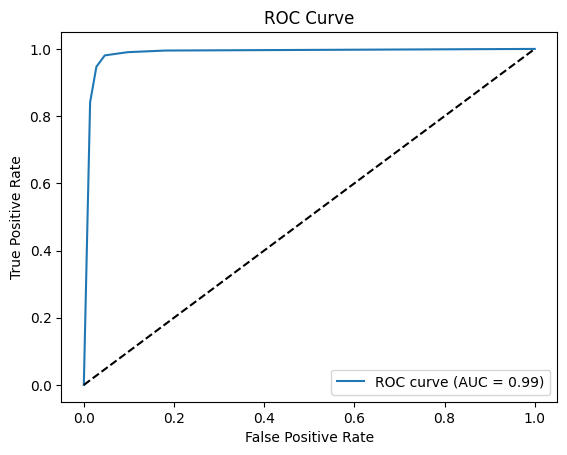

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Use probabilities for ROC
y_prob = knn_model.predict_proba(x_test_scaled)[:, 1]
# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
print("AUC Score:", roc_auc)
# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array

uploaded = files.upload()
for fname in uploaded.keys():
    img = load_img(fname, target_size=(img_size, img_size))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)

    # Feature extraction
    img_feat = feature_extractor.predict(img, verbose=0)
    img_feat_scaled = scaler.transform(img_feat)

    # KNN prediction
    pred_class = knn_model.predict(img_feat_scaled)[0]
    label = "Normal" if pred_class == 0 else "Cataract"
    print(f"{fname} -> Prediction: {label}")

Saving nor5.jpg to nor5 (1).jpg
Saving c5.jpg to c5 (1).jpg
Saving c4.jpg to c4 (1).jpg
Saving Cataract image.jpg to Cataract image (1).jpg
Saving c2.jpg to c2 (1).jpg
Saving c1.jpg to c1 (1).jpg
Saving nor4.jpg to nor4 (1).jpg
Saving Normal Image.jpg to Normal Image (1).jpg
Saving nor2.jpg to nor2 (1).jpg
Saving nor1.jpg to nor1 (1).jpg
nor5 (1).jpg -> Prediction: Normal
c5 (1).jpg -> Prediction: Cataract
c4 (1).jpg -> Prediction: Cataract
Cataract image (1).jpg -> Prediction: Cataract
c2 (1).jpg -> Prediction: Cataract
c1 (1).jpg -> Prediction: Cataract
nor4 (1).jpg -> Prediction: Normal
Normal Image (1).jpg -> Prediction: Normal
nor2 (1).jpg -> Prediction: Normal
nor1 (1).jpg -> Prediction: Normal


MobileNet+Grad-CAM

In [ ]:
# import libraries
import os
import random
import tensorflow as tf
import cv2
import numpy as np
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D,Dense,Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# seeding
SEED=42
os.environ['PYTHONHASHSEED']=str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
# load data
from google.colab import drive
path="/content/drive/MyDrive/Fundus images/dataset"
os.listdir(path)
#count the number of images
normal_dir=os.path.join(path,"normal")
cataract_dir=os.path.join(path,"cataract")
normal_count=len(os.listdir(normal_dir))
cataract_count=len(os.listdir(cataract_dir))
print("normal_count:",normal_count)
print("cataract_count:",cataract_count)
img_size=224
x=[]  # images
y=[]  # labels
# load normal images
for img in os.listdir(normal_dir):
  img_path=os.path.join(normal_dir,img)
  img_arr=cv2.imread(img_path)
  img_arr=cv2.cvtColor(img_arr,cv2.COLOR_BGR2RGB)
  img_arr=cv2.resize(img_arr,(img_size,img_size))
  x.append(img_arr)   #image
  y.append(0)   #label
# load cataract images
for img in os.listdir(cataract_dir):
  img_path=os.path.join(cataract_dir,img)
  img_arr=cv2.imread(img_path)
  img_arr=cv2.cvtColor(img_arr,cv2.COLOR_BGR2RGB)
  img_arr=cv2.resize(img_arr,(img_size,img_size))
  x.append(img_arr)
  y.append(1)
x=np.array(x)
y=np.array(y)
x=preprocess_input(x)
print(x.shape)
print(y.shape)
from sklearn.model_selection import train_test_split
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.4, random_state=42, stratify=y)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

train_gen=ImageDataGenerator(rotation_range=10,width_shift_range=0.1,height_shift_range=0.1,zoom_range=0.2,horizontal_flip=True)
val_gen=ImageDataGenerator()

normal_count: 1074
cataract_count: 1038
(2112, 224, 224, 3)
(2112,)
(1267, 224, 224, 3)
(422, 224, 224, 3)
(423, 224, 224, 3)
(1267,)
(422,)
(423,)


In [ ]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights=dict(enumerate(class_weights))
print(class_weights)
# load model
base_model=MobileNetV2(weights="imagenet",include_top=False,input_shape=(img_size,img_size,3))
base_model.trainable=False
x= base_model.output
x= GlobalAveragePooling2D()(x)
x= Dense(128,activation="relu")(x)
x= Dropout(0.5)(x)
output=Dense(1,activation="sigmoid")(x)
model=Model(inputs=base_model.input,outputs=output)
model.compile(optimizer=Adam(learning_rate=1e-4),loss="binary_crossentropy",metrics=["accuracy"])
model.summary()
history=model.fit(train_gen.flow(x_train,y_train,batch_size=32),epochs=25,validation_data=val_gen.flow(x_val,y_val),class_weight=class_weights)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

{0: np.float64(0.9836956521739131), 1: np.float64(1.0168539325842696)}
Epoch 1/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.7995 - loss: 0.4468 - val_accuracy: 0.9313 - val_loss: 0.2102
Epoch 2/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.9274 - loss: 0.2110 - val_accuracy: 0.9408 - val_loss: 0.1578
Epoch 3/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.9416 - loss: 0.1717 - val_accuracy: 0.9408 - val_loss: 0.1372
Epoch 4/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.9392 - loss: 0.1638 - val_accuracy: 0.9479 - val_loss: 0.1261
Epoch 5/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.9408 - loss: 0.1501 - val_accuracy: 0.9526 - val_loss: 0.1239
Epoch 6/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 100s 3s/step - accuracy: 0.9487 - loss: 0.1499 - val_accuracy: 0.9550 - val_loss: 0.1161
Epoch 7/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.9566 - loss: 0.1174 - val_accuracy: 0.9597 - val_loss: 0.1096
Epoch 8/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/

In [ ]:
loss,accuracy=model.evaluate(x_test,y_test)
print("loss:",loss)
print("accuracy:",accuracy)
from sklearn.metrics import classification_report,confusion_matrix
y_pred=model.predict(x_test)
y_pred=np.round(y_pred)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

14/14 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9598 - loss: 0.1210
loss: 0.12100795656442642
accuracy: 0.9598108530044556
14/14 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       215
           1       0.98      0.94      0.96       208

    accuracy                           0.96       423
   macro avg       0.96      0.96      0.96       423
weighted avg       0.96      0.96      0.96       423

[[210   5]
 [ 12 196]]


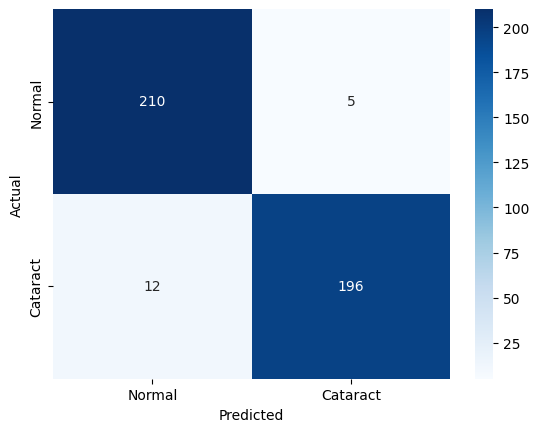

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix(y_test, np.round(y_pred)), annot=True, fmt='d', cmap='Blues', xticklabels=['Normal','Cataract'], yticklabels=['Normal','Cataract'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Saving Normal Image (1).jpg to Normal Image (1) (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Normal Image (1) (1).jpg → Normal (prob=0.00)


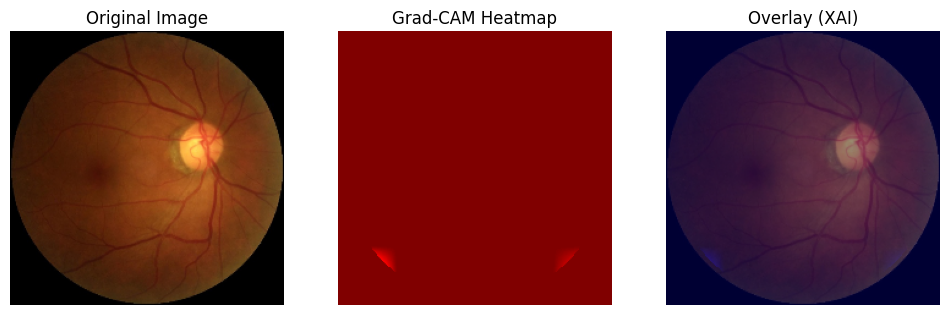

Severity: Normal
Affected Area: 0.07%


In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from google.colab import files

uploaded = files.upload()
for fname in uploaded.keys():
    img = load_img(fname, target_size=(img_size, img_size))
    img = img_to_array(img)
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)
    prob = model.predict(img)[0][0]
    label = "Cataract" if prob >= 0.5 else "Normal"
    print(f"{fname} → {label} (prob={prob:.2f})")

# import libraries
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Create gradcam model
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]  # cataract probability

    # Compute gradients
    grads = tape.gradient(loss, conv_outputs)

    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the feature maps
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()
img_path = fname  # uploaded image
img = load_img(img_path, target_size=(img_size, img_size))
img_array = img_to_array(img)
img_array = preprocess_input(img_array)
img_array = np.expand_dims(img_array, axis=0)

heatmap = make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name="Conv_1"
)
img = cv2.imread(img_path)
img = cv2.resize(img, (img_size, img_size))

height,width= img.shape[:2]
mask= np.zeros((height,width),np.uint8)
center=(width//2,height//2)
radius=min(width,height)//2-5
cv2.circle(mask,center,radius,255,-1)

heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap = np.uint8(255 * heatmap)
heatmap= cv2.bitwise_and(heatmap,heatmap,mask=mask)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
masked_img=cv2.bitwise_and(img,img,mask=mask)
superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.title("Overlay (XAI)")
plt.axis("off")
plt.show()
# severity level
_, binary_map = cv2.threshold(heatmap, 180, 255, cv2.THRESH_BINARY)
affected_pixels = np.sum(binary_map > 0)
total_pixels = binary_map.size
affected_ratio = affected_pixels / total_pixels
if affected_ratio < 0.10:
  severity = "Normal"
elif affected_ratio < 0.25:
    severity = "Mild Cataract"
elif affected_ratio < 0.45:
    severity = "Moderate Cataract"
else:
    severity = "Severe Cataract"

print(f"Severity: {severity}")
print(f"Affected Area: {affected_ratio*100:.2f}%")

14/14 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step
AUC Score: 0.9938059033989267


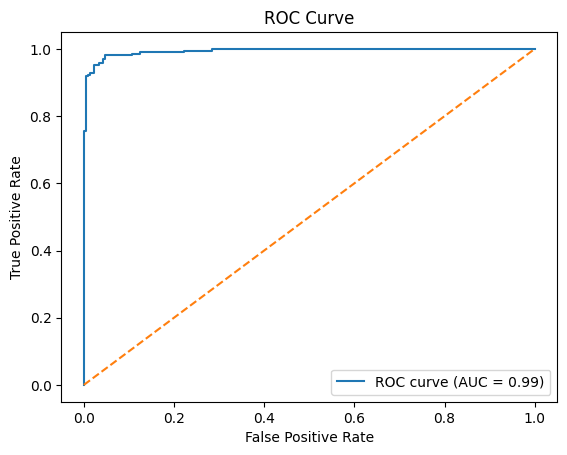

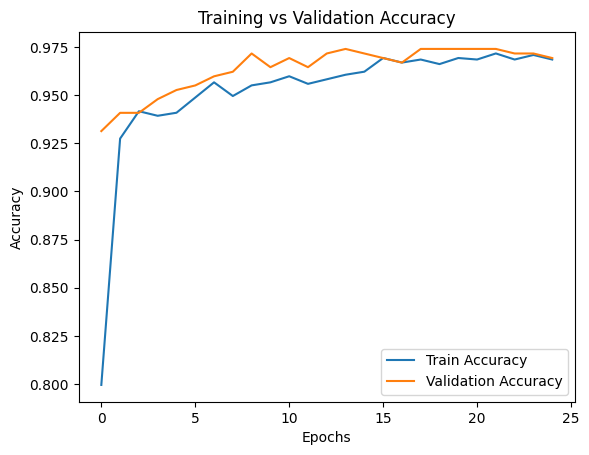

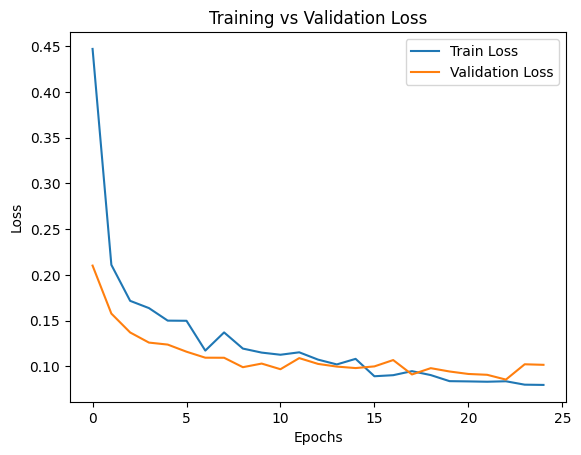

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Predict probabilities
y_pred_prob = model.predict(x_test).ravel()

# 2. ROC Curve & AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

# 3. Training vs Validation Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

# 4. Training vs Validation Loss
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

Saving c2.jpg to c2 (2).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
c2 (2).jpg → Cataract (prob=0.72)


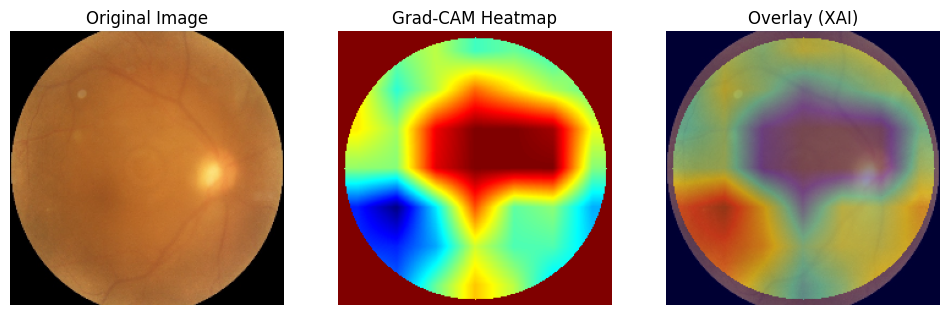

Severity: Moderate Cataract
Affected Area: 29.98%


In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from google.colab import files

uploaded = files.upload()
for fname in uploaded.keys():
    img = load_img(fname, target_size=(img_size, img_size))
    img = img_to_array(img)
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)
    prob = model.predict(img)[0][0]
    label = "Cataract" if prob >= 0.5 else "Normal"
    print(f"{fname} → {label} (prob={prob:.2f})")

# import libraries
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Create gradcam model
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]  # cataract probability

    # Compute gradients
    grads = tape.gradient(loss, conv_outputs)

    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the feature maps
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()
img_path = fname  # uploaded image
img = load_img(img_path, target_size=(img_size, img_size))
img_array = img_to_array(img)
img_array = preprocess_input(img_array)
img_array = np.expand_dims(img_array, axis=0)

heatmap = make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name="Conv_1"
)
img = cv2.imread(img_path)
img = cv2.resize(img, (img_size, img_size))

height,width= img.shape[:2]
mask= np.zeros((height,width),np.uint8)
center=(width//2,height//2)
radius=min(width,height)//2-5
cv2.circle(mask,center,radius,255,-1)

heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap = np.uint8(255 * heatmap)
heatmap= cv2.bitwise_and(heatmap,heatmap,mask=mask)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
masked_img=cv2.bitwise_and(img,img,mask=mask)
superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.title("Overlay (XAI)")
plt.axis("off")
plt.show()
# severity level
_, binary_map = cv2.threshold(heatmap, 180, 255, cv2.THRESH_BINARY)
affected_pixels = np.sum(binary_map > 0)
total_pixels = binary_map.size
affected_ratio = affected_pixels / total_pixels
if affected_ratio < 0.10:
  severity = "Normal"
elif affected_ratio < 0.25:
    severity = "Mild Cataract"
elif affected_ratio < 0.45:
    severity = "Moderate Cataract"
else:
    severity = "Severe Cataract"

print(f"Severity: {severity}")
print(f"Affected Area: {affected_ratio*100:.2f}%")

pretrained vit (Mobilevit-s)

In [ ]:
!pip install --upgrade --force-reinstall keras-cv-attention-models

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.1/191.1 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 452.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 806.1/806.1 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.0/802.0 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 981.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 647.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import tensorflow as tf
print("TensorFlow:", tf.__version__)
# import libraries
import numpy as np
import cv2
from keras_cv_attention_models import mobilevit
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
path = "/content/drive/MyDrive/Fundus images/dataset"

normal_dir = os.path.join(path, "normal")
cataract_dir = os.path.join(path, "cataract")

print("Normal images:", len(os.listdir(normal_dir)))
print("Cataract images:", len(os.listdir(cataract_dir)))
IMG_SIZE = 224

x = []
y = []

def load_images(folder, label):
    for img in os.listdir(folder):
        img_path = os.path.join(folder, img)
        img_arr = cv2.imread(img_path)
        if img_arr is None:
            continue
        img_arr = cv2.cvtColor(img_arr, cv2.COLOR_BGR2RGB)
        img_arr = cv2.resize(img_arr, (IMG_SIZE, IMG_SIZE))
        x.append(img_arr)
        y.append(label)

load_images(normal_dir, 0)
load_images(cataract_dir, 1)

X = np.array(x, dtype="float32") / 255.0
y = np.array(y)

print(X.shape, y.shape)
from sklearn.model_selection import train_test_split
x_train, x_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

TensorFlow: 2.21.0
Normal images: 1074
Cataract images: 1038
(2112, 224, 224, 3) (2112,)
(1267, 224, 224, 3)
(422, 224, 224, 3)
(423, 224, 224, 3)


In [ ]:
from sklearn.utils import class_weight
# Calculate class weights
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

train_gen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator()
train_generator = train_gen.flow(x_train, y_train, batch_size=16)
val_generator = val_gen.flow(x_val, y_val, batch_size=16)
# load model
base_model = mobilevit.MobileViT_S(
    input_shape=(224,224,3),
    num_classes=0,
    pretrained="imagenet"
)

for layer in base_model.layers[:-40]:
    layer.trainable = False
for layer in base_model.layers[-40:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(base_model.input, output)
# ▸ Compile
model.compile(
    optimizer=Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
# ▸ Train (with class weights)
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights
)
# ▸ Step 11: Evaluate on TEST set
test_loss, test_acc = model.evaluate(x_test, y_test, batch_size=16)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

Class weights: {0: np.float64(0.9836956521739131), 1: np.float64(1.0168539325842696)}
23147384/23147384 [==============================] - 0s 0us/step
>>>> Load pretrained from: /root/.keras/models/mobilevit_s_imagenet.h5
Epoch 1/20
80/80 [==============================] - 472s 6s/step - loss: 0.4257 - accuracy: 0.8627 - val_loss: 0.2150 - val_accuracy: 0.9242
Epoch 2/20
80/80 [==============================] - 386s 5s/step - loss: 0.2012 - accuracy: 0.9416 - val_loss: 0.1583 - val_accuracy: 0.9408
Epoch 3/20
80/80 [==============================] - 393s 5s/step - loss: 0.1663 - accuracy: 0.9400 - val_loss: 0.1359 - val_accuracy: 0.9502
Epoch 4/20
80/80 [==============================] - 393s 5s/step - loss: 0.1181 - accuracy: 0.9605 - val_loss: 0.1217 - val_accuracy: 0.9526
Epoch 5/20
80/80 [==============================] - 389s 5s/step - loss: 0.1200 - accuracy: 0.9605 - val_loss: 0.1209 - val_accuracy: 0.9597
Epoch 6/20
80/80 [==============================] - 386s 5s/step - loss: 

14/14 [==============================] - 90s 6s/step
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       215
           1       0.99      0.96      0.97       208

    accuracy                           0.97       423
   macro avg       0.97      0.97      0.97       423
weighted avg       0.97      0.97      0.97       423

[[212   3]
 [  9 199]]


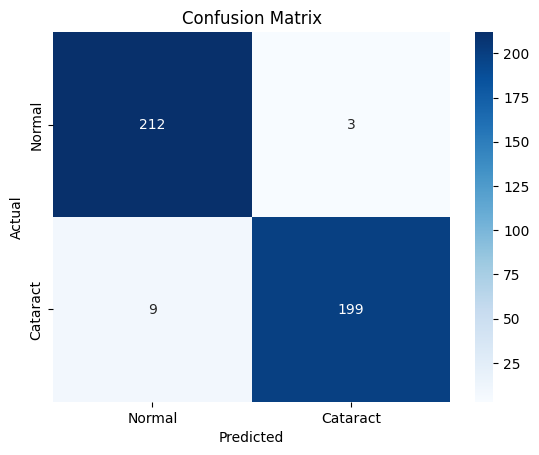

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
y_pred=model.predict(x_test)
y_pred=np.round(y_pred)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix(y_test, np.round(y_pred)), annot=True, fmt='d', cmap='Blues', xticklabels=['Normal','Cataract'], yticklabels=['Normal','Cataract'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

14/14 [==============================] - 84s 5s/step
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       215
           1       0.99      0.96      0.97       208

    accuracy                           0.97       423
   macro avg       0.97      0.97      0.97       423
weighted avg       0.97      0.97      0.97       423

[[212   3]
 [  9 199]]


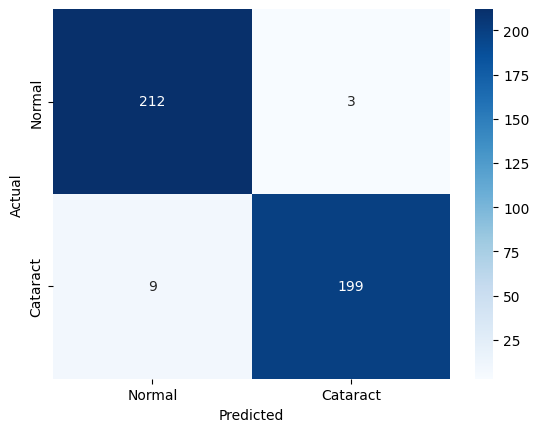

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
y_pred=model.predict(x_test)
y_pred=np.round(y_pred)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix(y_test, np.round(y_pred)), annot=True, fmt='d', cmap='Blues', xticklabels=['Normal','Cataract'], yticklabels=['Normal','Cataract'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

14/14 [==============================] - 140s 9s/step


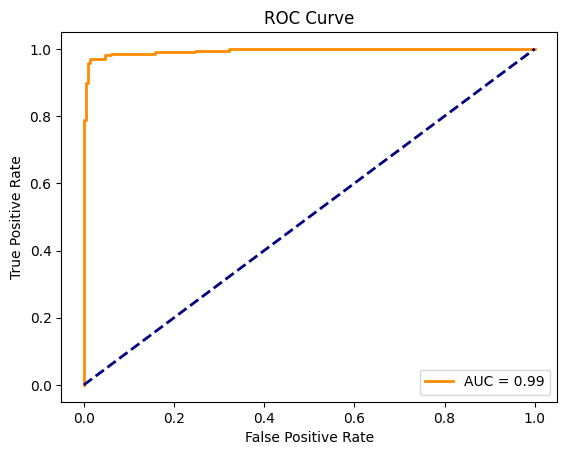

AUC: 0.9945214669051878


In [ ]:
from sklearn.metrics import roc_curve, auc
y_pred_prob = model.predict(x_test)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label= "AUC = %0.2f" % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()
print("AUC:", roc_auc)

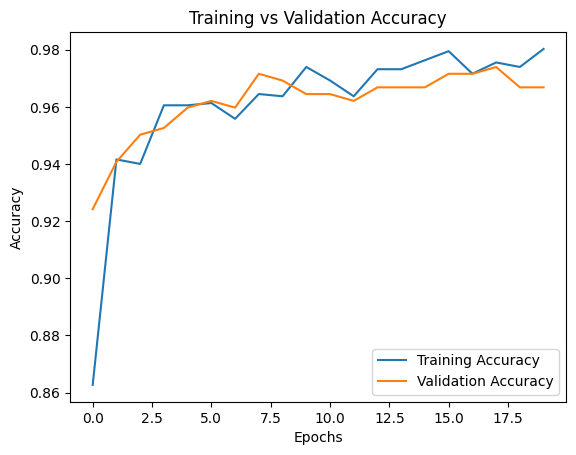

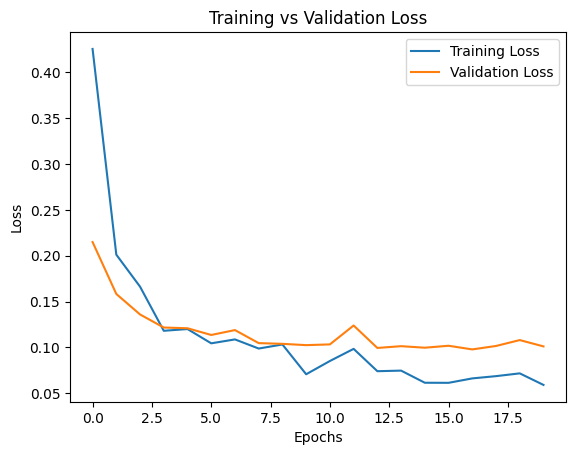

In [ ]:
# plot accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()
plt.figure()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [ ]:
from google.colab import files
import cv2
import numpy as np
import os

uploaded = files.upload()

for img_name in uploaded.keys():
    img = cv2.imread(img_name)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224,224))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)[0][0]

    if pred > 0.5:
        print(f"{img_name}: Cataract ({pred:.2f})")
    else:
        print(f"{img_name}: Normal ({pred:.2f})")


Saving nor5.jpg to nor5.jpg
Saving c5.jpg to c5.jpg
Saving c4.jpg to c4.jpg
Saving Cataract image.jpg to Cataract image.jpg
Saving c2.jpg to c2.jpg
Saving c1.jpg to c1.jpg
Saving nor4.jpg to nor4.jpg
Saving Normal Image.jpg to Normal Image.jpg
Saving nor2.jpg to nor2.jpg
Saving nor1.jpg to nor1.jpg
1/1 [==============================] - 4s 4s/step
nor5.jpg: Normal (0.01)
1/1 [==============================] - 0s 287ms/step
c5.jpg: Cataract (0.96)
1/1 [==============================] - 0s 270ms/step
c4.jpg: Cataract (0.97)
1/1 [==============================] - 0s 271ms/step
Cataract image.jpg: Cataract (1.00)
1/1 [==============================] - 0s 272ms/step
c2.jpg: Cataract (0.99)
1/1 [==============================] - 0s 289ms/step
c1.jpg: Cataract (0.98)
1/1 [==============================] - 0s 273ms/step
nor4.jpg: Normal (0.00)
1/1 [==============================] - 0s 250ms/step
Normal Image.jpg: Normal (0.00)
1/1 [==============================] - 0s 169ms/step
nor2.jpg: Norm

vit(vit-base-patch224) pytorch

In [ ]:
!pip install --upgrade --force-reinstall huggingface_hub
!pip install torch torchvision accelerate scikit-learn transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 618.0/618.0 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.3/108.3 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.5/31

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.datasets import ImageFolder
from torchvision import transforms
from PIL import Image
from transformers import ViTImageProcessor, ViTForImageClassification
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
train_augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])

def vit_preprocess(image, train=True):
    if train:
        image = train_augment(image)
    return processor(images=image, return_tensors="pt")["pixel_values"].squeeze(0)
class ViTDataset(Dataset):
    def __init__(self, folder_path, train=True):
        self.folder = ImageFolder(root=folder_path)
        self.samples = [(p, l) for p, l in self.folder.samples if l in [0, 1]]
        self.train = train

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        pixel_values = vit_preprocess(image, self.train)
        return pixel_values, label
DATASET_PATH = "/content/drive/MyDrive/Fundus images/dataset"
BATCH_SIZE = 8

full_dataset = ViTDataset(DATASET_PATH, train=True)

total_size = len(full_dataset)
train_size = int(0.6 * total_size)
val_size = int(0.2 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Disable augmentation for val & test
val_dataset.dataset.train = False
test_dataset.dataset.train = False

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

In [ ]:
import random
SEED= 42
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
device = "cuda" if torch.cuda.is_available() else "cpu"
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=2,
    ignore_mismatched_sizes=True
)

# Freeze ViT backbone
for param in model.vit.parameters():
    param.requires_grad = False

model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-5)
EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Training Loss: {train_loss/len(train_loader):.4f}")

    # Validation
    model.eval()
    val_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).logits
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    print(f"Validation Loss: {val_loss/len(val_loader):.4f}")
    print(f"Validation Accuracy: {correct/total:.4f}")


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
100%|██████████| 161/161 [22:10<00:00,  8.27s/it]



Epoch 1/10
Training Loss: 0.8653
Validation Loss: 0.6063
Validation Accuracy: 0.6745


...

100%|██████████| 161/161 [13:29<00:00,  5.03s/it]



Epoch 6/10
Training Loss: 0.1738
Validation Loss: 0.1669
Validation Accuracy: 0.9438


100%|██████████| 161/161 [13:29<00:00,  5.03s/it]



Epoch 7/10
Training Loss: 0.1632
Validation Loss: 0.1565
Validation Accuracy: 0.9461


 60%|██████    | 97/161 [08:11<05:21,  5.03s/it]

In [ ]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images).logits
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

print("\nClassification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=["Normal", "Cataract"]
))
